# Разведочный анализ данных: диагностика сердечных заболеваний

Задача — бинарная классификация: по клиническим показателям пациента предсказать значение `target`.

Источник: [Heart Disease Dataset](https://www.kaggle.com/datasets/krishujeniya/heart-diseae) (Cleveland, UCI).

## Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# 1. Загрузка данных и знакомство с ними

In [2]:
df = pd.read_csv('../data/heart.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Датасет содержит 303 записи и 14 столбцов — 13 признаков и целевая переменная:

| Признак | Тип | Описание |
|---|---|---|
| `age` | числовой | возраст, лет |
| `sex` | категориальный | пол: 1 — мужской, 0 — женский |
| `cp` | категориальный | тип боли в груди: 0 — типичная стенокардия, 1 — атипичная, 2 — не связанная с сердцем, 3 — бессимптомно |
| `trestbps` | числовой | артериальное давление в покое, мм рт. ст. |
| `chol` | числовой | холестерин, мг/дл |
| `fbs` | категориальный | сахар в крови натощак > 120 мг/дл (1 — да) |
| `restecg` | категориальный | результат ЭКГ в покое (0, 1, 2) |
| `thalach` | числовой | максимальная достигнутая частота пульса |
| `exang` | категориальный | стенокардия при нагрузке (1 — да) |
| `oldpeak` | числовой | депрессия сегмента ST при нагрузке |
| `slope` | категориальный | наклон сегмента ST (0, 1, 2) |
| `ca` | категориальный | число крупных сосудов, окрашенных при флюороскопии (0–3) |
| `thal` | категориальный | результат стресс-теста с таллием (1, 2, 3) |
| `target` | **целевая** | класс пациента: 0 / 1 |

In [5]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target = 'target'

print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))

Числовых признаков: 5
Категориальных признаков: 8


In [6]:
print('Пропуски по столбцам:')
print(df.isna().sum().to_string())

Пропуски по столбцам:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


In [7]:
print('Распределение целевой переменной:')
print(df[target].value_counts().to_string())
print()
print('Уникальные значения категориальных признаков:')
for col in categorical_features:
    print(f'  {col}: {sorted(df[col].unique())}')

Распределение целевой переменной:
target
1    165
0    138

Уникальные значения категориальных признаков:
  sex: [np.int64(0), np.int64(1)]
  cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  fbs: [np.int64(0), np.int64(1)]
  restecg: [np.int64(0), np.int64(1), np.int64(2)]
  exang: [np.int64(0), np.int64(1)]
  slope: [np.int64(0), np.int64(1), np.int64(2)]
  ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  thal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### Вывод

- Пропущенных значений (`NaN`) в датасете нет, все столбцы имеют числовой тип `int64` / `float64`.
- Классы целевой переменной сбалансированы: 165 против 138 — балансировка выборки не потребуется.
- Все категориальные признаки закодированы целыми числами, но **два из них выходят за границы своей кодировки**:
  - `ca` по описанию принимает значения 0–3, а в данных встречается 4;
  - `thal` по описанию принимает значения 1–3, а в данных встречается 0.

  В исходном датасете UCI это были пропуски, которые при публикации заполнили нулём и четвёркой. Их нужно обработать на этапе очистки.
- Числовые признаки имеют сильно разный масштаб (`chol` — сотни, `oldpeak` — единицы), при обучении модели потребуется нормировка.

# 2. Очистка данных

## 2.1 Дубликаты

In [8]:
print('Полных дубликатов:', df.duplicated().sum())
df[df.duplicated(keep=False)]

Полных дубликатов: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [9]:
df = df.drop_duplicates()
print('После удаления дубликатов:', df.shape)

После удаления дубликатов: (302, 14)


## 2.2 Невалидные значения категориальных признаков

In [10]:
print('Записей с ca == 4  :', (df['ca'] == 4).sum())
print('Записей с thal == 0:', (df['thal'] == 0).sum())
print('Пересечение        :', ((df['ca'] == 4) & (df['thal'] == 0)).sum())

Записей с ca == 4  : 4
Записей с thal == 0: 2
Пересечение        : 0


In [11]:
before = len(df)
df = df[(df['ca'] != 4) & (df['thal'] != 0)]
print(f'Удалено записей: {before - len(df)}')
print('Размер выборки:', df.shape)

Удалено записей: 6
Размер выборки: (296, 14)


Удалено 6 записей из 302 (2.0% выборки). Обратите внимание: в исходных данных записей
с `ca = 4` было пять, но одна из них и оказалась тем самым дубликатом, удалённым на шаге 2.1.

Восстанавливать эти значения не стали: доля мала, а способа корректно восстановить
результат медицинского обследования нет.

## 2.3 Проверка числовых признаков на валидность

In [12]:
print(df[numeric_features].agg(['min', 'max']).T.to_string())

            min    max
age        29.0   77.0
trestbps   94.0  200.0
chol      126.0  564.0
thalach    71.0  202.0
oldpeak     0.0    6.2


Все числовые признаки лежат в физиологически правдоподобных диапазонах:
давление 94–200 мм рт. ст., холестерин 126–564 мг/дл, пульс 71–202 уд/мин,
возраст 29–77 лет. Невалидных значений нет — удалять нечего.

## 2.4 Приведение типов данных

In [13]:
for col in categorical_features + [target]:
    df[col] = df[col].astype('int8')

df['age'] = df['age'].astype('int8')
df['trestbps'] = df['trestbps'].astype('int16')
df['chol'] = df['chol'].astype('int16')
df['thalach'] = df['thalach'].astype('int16')
df['oldpeak'] = df['oldpeak'].astype('float32')

df.info()

<class 'pandas.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       296 non-null    int8   
 1   sex       296 non-null    int8   
 2   cp        296 non-null    int8   
 3   trestbps  296 non-null    int16  
 4   chol      296 non-null    int16  
 5   fbs       296 non-null    int8   
 6   restecg   296 non-null    int8   
 7   thalach   296 non-null    int16  
 8   exang     296 non-null    int8   
 9   oldpeak   296 non-null    float32
 10  slope     296 non-null    int8   
 11  ca        296 non-null    int8   
 12  thal      296 non-null    int8   
 13  target    296 non-null    int8   
dtypes: float32(1), int16(3), int8(10)
memory usage: 8.1 KB


Понижение разрядности типов сократило объём датасета в памяти примерно в 4 раза.
Для выборки в 300 строк это несущественно, но привычка полезная, а типы теперь
явно отражают природу признаков.

## 2.5 Новый признак: возрастная группа

In [14]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[28, 40, 50, 60, 70, 80],
    labels=['29-40', '41-50', '51-60', '61-70', '71-80'],
)
print(df['age_group'].value_counts().sort_index().to_string())

age_group
29-40     17
41-50     75
51-60    125
61-70     73
71-80      6


Признак `age_group` создан для анализа: непрерывный возраст плохо читается на графиках,
а группы по десятилетиям позволяют сравнивать доли классов между возрастными когортами.

# 3. Анализ признаков для модели

## 3.1 Распределение числовых признаков по классам (интерактивный график)

График интерактивный: можно наводить курсор на «ящик», чтобы увидеть точные значения
квартилей, и скрывать классы кликом по легенде.

In [15]:
long = df.melt(id_vars=target, value_vars=numeric_features,
               var_name='Признак', value_name='Значение')
long['Класс'] = long[target].astype(str)

fig = px.box(
    long, x='Класс', y='Значение', color='Класс',
    facet_col='Признак', facet_col_spacing=0.05,
    category_orders={'Признак': numeric_features},
    color_discrete_map={'0': '#d62728', '1': '#2ca02c'},
    title='Распределение числовых признаков по классам',
    points='outliers',
)
fig.update_yaxes(matches=None, showticklabels=True)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig.update_layout(width=1200, height=500)

fig.write_html('numeric_boxplot.html', include_plotlyjs='cdn')
fig.write_image('numeric_boxplot.png', width=1200, height=500)
fig.show()

### Вывод

- `thalach` (максимальный пульс) — самый выразительный числовой признак: медиана класса 1 около 161 уд/мин
  против 141 у класса 0, «ящики» почти не перекрываются.
- `oldpeak` у класса 1 прижат к нулю (медиана 0.2) против 1.4 у класса 0.
- `age`: класс 1 в среднем на 4 года моложе (52.6 против 56.7).
- `chol` и `trestbps` распределены у обоих классов практически одинаково — разделяющей способности почти нет.
  У `chol` заметен выброс в 564 мг/дл.

## 3.2 Корреляционная матрица

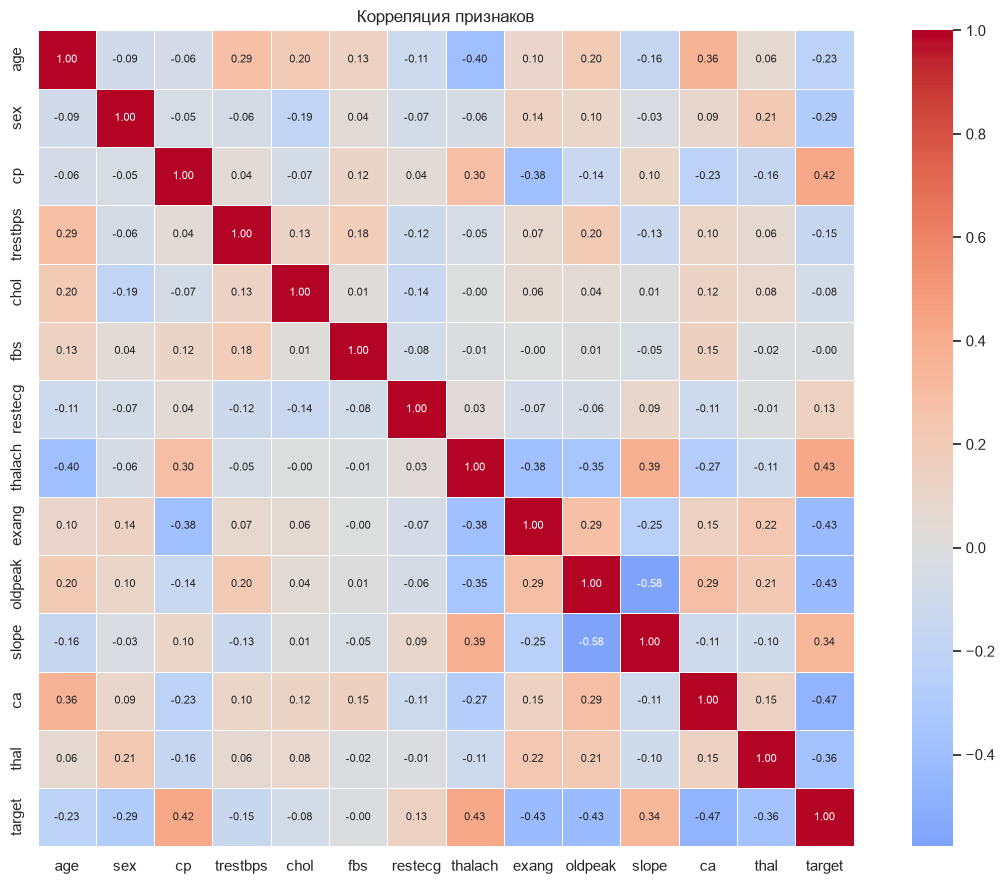

In [16]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns='age_group').corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5, annot_kws={'size': 8})
plt.title('Корреляция признаков')
plt.tight_layout()
plt.savefig('correlation.png', dpi=120)
plt.show()

In [17]:
corr[target].drop(target).sort_values(key=abs, ascending=False).round(3)

ca         -0.467
oldpeak    -0.429
thalach     0.427
exang      -0.425
cp          0.423
thal       -0.364
slope       0.338
sex        -0.285
age        -0.225
trestbps   -0.149
restecg     0.132
chol       -0.077
fbs        -0.005
Name: target, dtype: float64

### Вывод

- Сильнее всего с целевой переменной связаны `ca` (−0.47), `oldpeak` (−0.43), `thalach` (+0.43),
  `exang` (−0.43) и `cp` (+0.42).
- Практически бесполезны `fbs` (−0.005) и `chol` (−0.08) — кандидаты на удаление при отборе признаков.
- Заметная взаимная корреляция есть у пары `slope` / `oldpeak` (−0.58) — оба описывают поведение
  сегмента ST, то есть частично дублируют друг друга. При отборе признаков имеет смысл оставить один.
- Мультиколлинеарности между остальными признаками нет: все прочие попарные корреляции по модулю < 0.4.

## 3.3 Распределение числовых признаков по целевой переменной

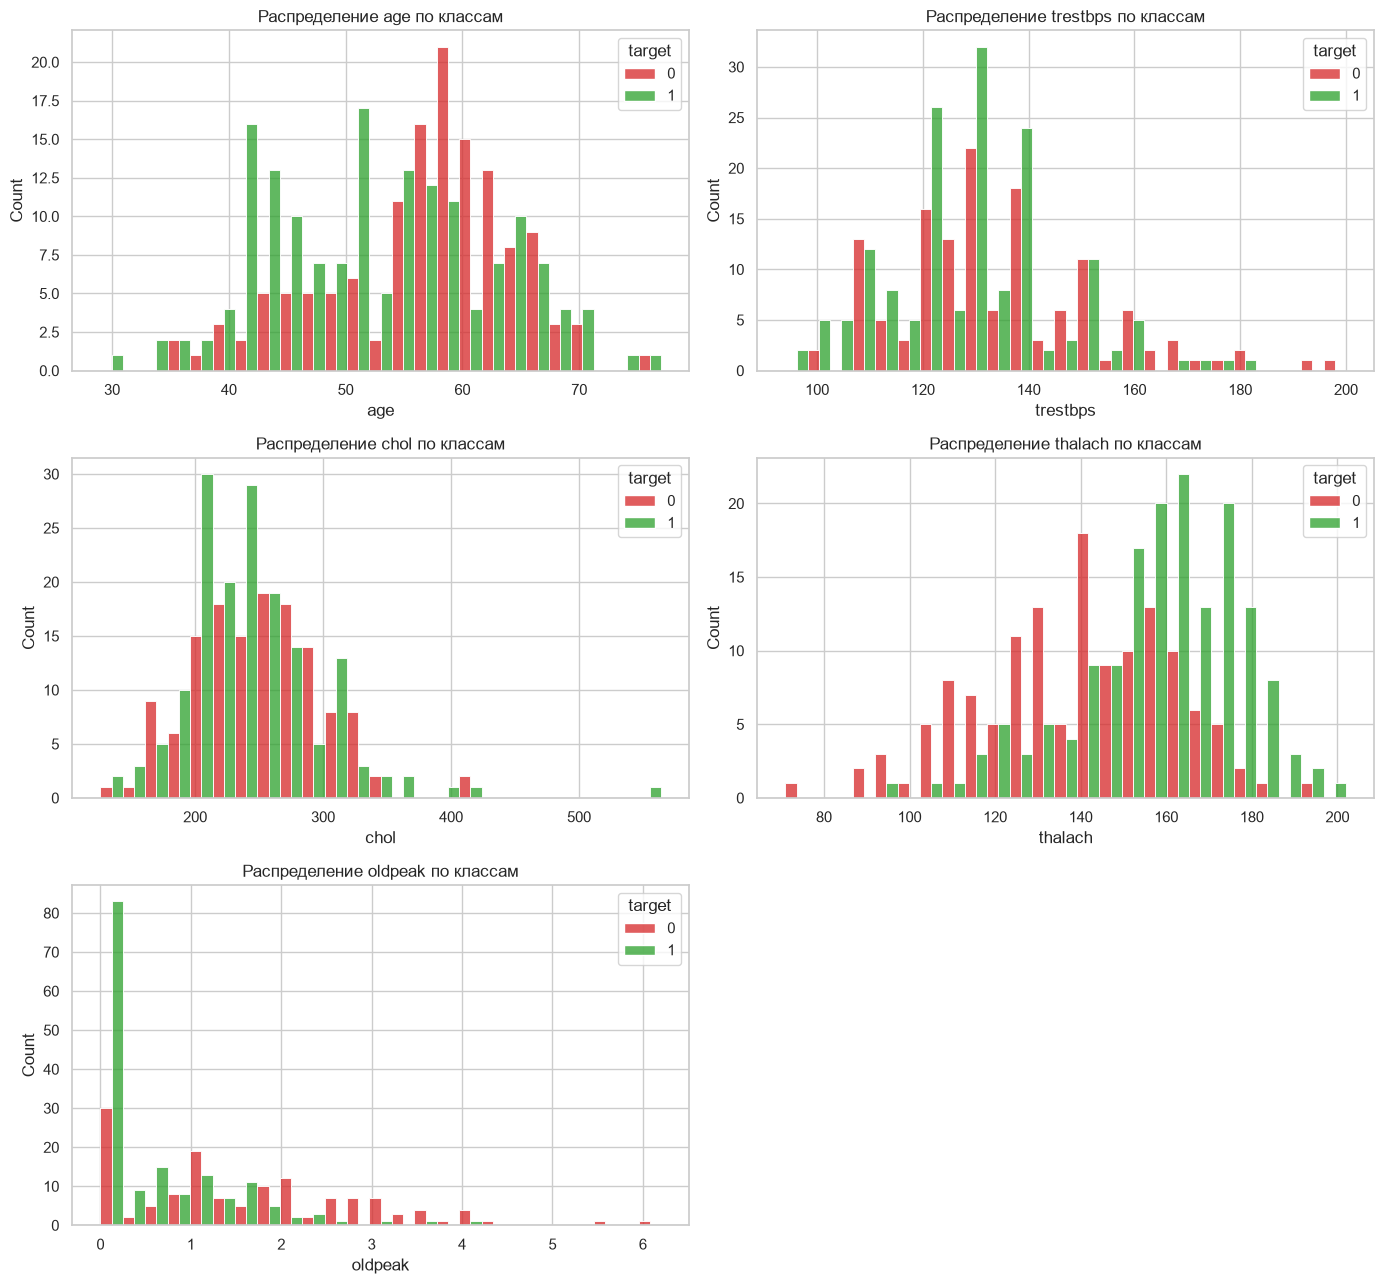

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.histplot(data=df, x=col, hue=target, ax=ax, bins=25,
                 palette={0: '#d62728', 1: '#2ca02c'}, multiple='dodge')
    ax.set_title(f'Распределение {col} по классам')

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('numeric_by_target.png', dpi=120)
plt.show()

In [19]:
df.groupby(target)[numeric_features].mean().round(1)

,age,trestbps,chol,thalach,oldpeak
target,,,,,
0,56.7,134.5,251.5,138.9,1.6
1,52.6,129.2,243.5,158.6,0.6


### Вывод

- `thalach`: класс 0 сосредоточен в диапазоне 110–150 уд/мин, класс 1 — в 150–180. Это самый
  сильный числовой разделитель.
- `oldpeak`: у класса 1 подавляющее большинство наблюдений равно нулю, у класса 0 значения
  растянуты до 6.2. Признак почти бинарно разделяет группы по условию «oldpeak > 0».
- `age`: распределения сильно перекрываются, самостоятельной разделяющей силы мало,
  но в сочетании с полом признак работает (см. график 3.6).
- `chol` и `trestbps`: гистограммы классов накладываются друг на друга почти полностью.

## 3.4 Распределение категориальных признаков по целевой переменной

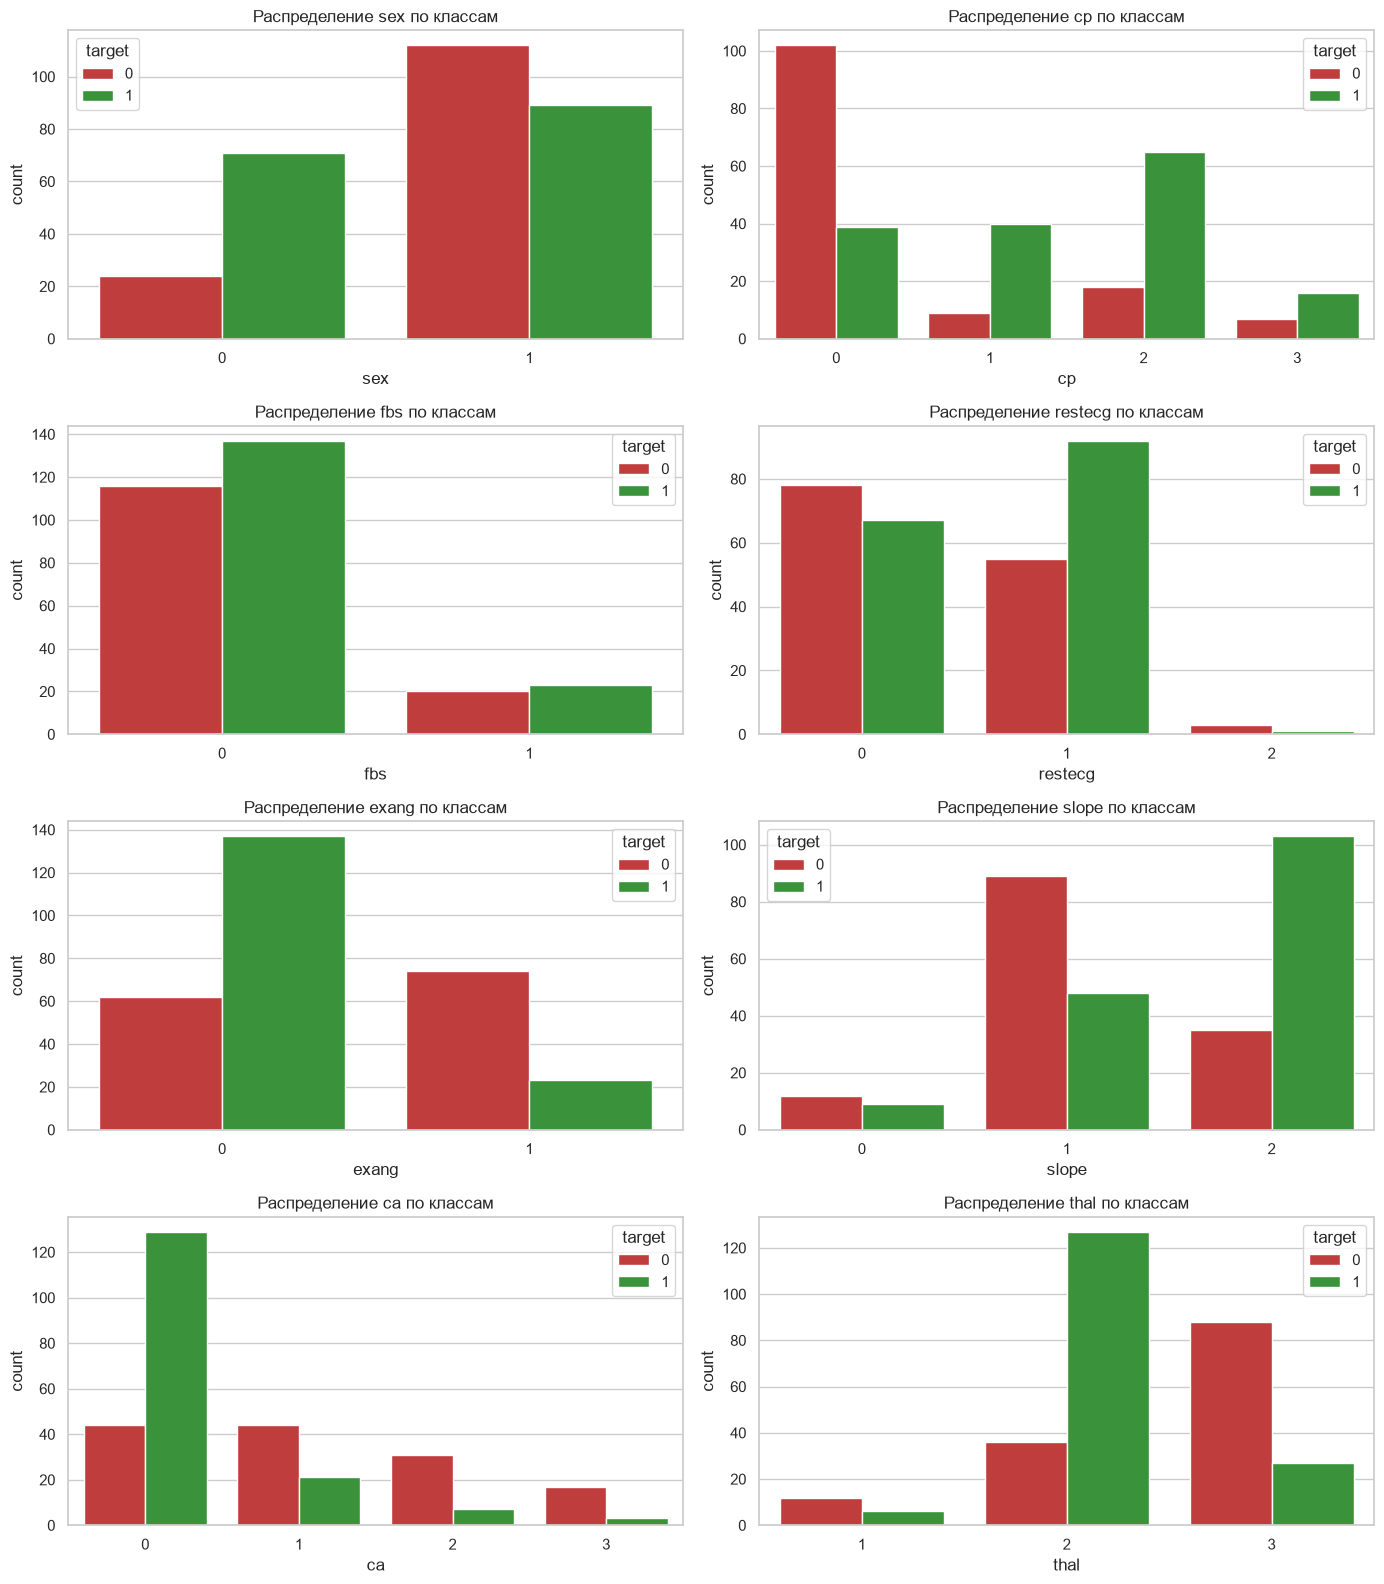

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    sns.countplot(data=df, x=col, hue=target, ax=ax,
                  palette={0: '#d62728', 1: '#2ca02c'})
    ax.set_title(f'Распределение {col} по классам')

plt.tight_layout()
plt.savefig('categorical_by_target.png', dpi=120)
plt.show()

In [21]:
for col in categorical_features:
    stat = df.groupby(col)[target].agg(['size', 'mean']).round(2)
    stat.columns = ['кол-во', 'доля класса 1']
    print(f'--- {col} ---')
    print(stat.to_string(), end='\n\n')

--- sex ---
     кол-во  доля класса 1
sex                       
0        95           0.75
1       201           0.44

--- cp ---
    кол-во  доля класса 1
cp                       
0      141           0.28
1       49           0.82
2       83           0.78
3       23           0.70

--- fbs ---
     кол-во  доля класса 1
fbs                       
0       253           0.54
1        43           0.53

--- restecg ---
         кол-во  доля класса 1
restecg                       
0           145           0.46
1           147           0.63
2             4           0.25

--- exang ---
       кол-во  доля класса 1
exang                       
0         199           0.69
1          97           0.24

--- slope ---
       кол-во  доля класса 1
slope                       
0          21           0.43
1         137           0.35
2         138           0.75

--- ca ---
    кол-во  доля класса 1
ca                       
0      173           0.75
1       65           0.32
2       38  

### Вывод

- `ca` — самый информативный категориальный признак: при `ca = 0` доля класса 1 составляет 0.75,
  при `ca = 3` падает до 0.15. Зависимость строго монотонная.
- `thal`: значение 2 даёт долю класса 1 равную 0.78, значения 1 и 3 — 0.33 и 0.23.
- `cp`: при `cp = 0` (типичная стенокардия) доля класса 1 — всего 0.28, при `cp = 1` — 0.82.
- `exang`: без стенокардии при нагрузке — 0.69, со стенокардией — 0.24.
- `sex`: у женщин доля класса 1 равна 0.75, у мужчин — 0.44. При этом мужчин в выборке
  вдвое больше (201 против 95) — выборка несбалансирована по полу.
- `fbs` и `restecg` разделяют классы слабо: доли 0.54 / 0.53 и 0.46 / 0.63.
  Категория `restecg = 2` представлена всего 4 записями и статистически не значима.

## 3.5 Связь возраста и максимального пульса

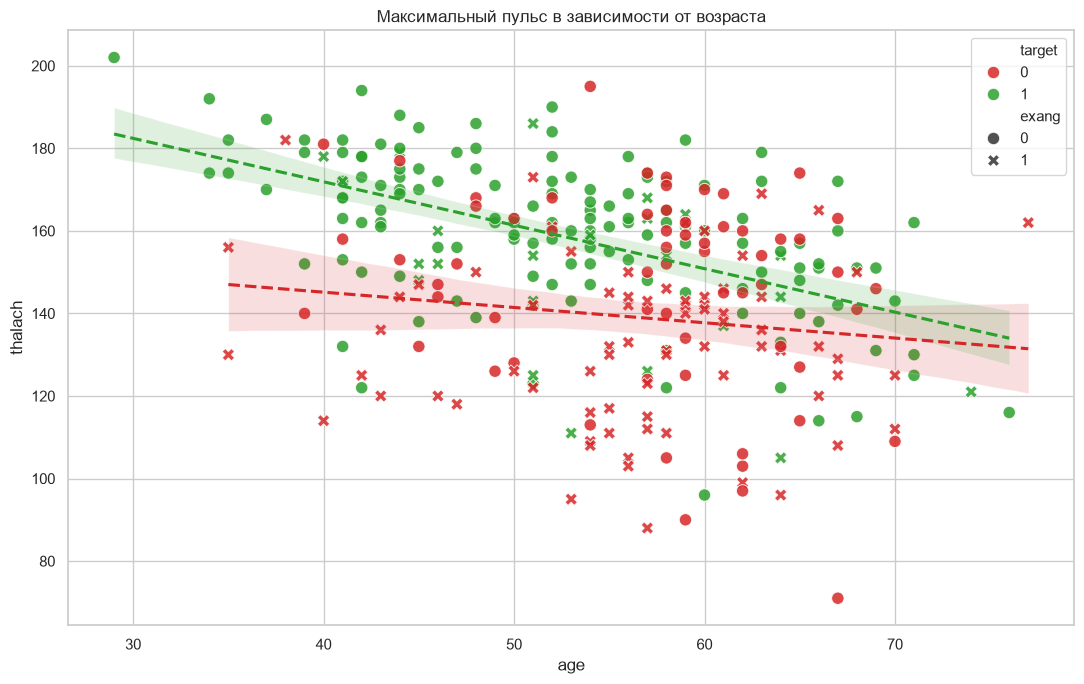

In [22]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x='age', y='thalach', hue=target, style='exang',
                palette={0: '#d62728', 1: '#2ca02c'}, s=80, alpha=.85)
sns.regplot(data=df[df[target] == 0], x='age', y='thalach',
            scatter=False, color='#d62728', line_kws={'ls': '--'})
sns.regplot(data=df[df[target] == 1], x='age', y='thalach',
            scatter=False, color='#2ca02c', line_kws={'ls': '--'})
plt.title('Максимальный пульс в зависимости от возраста')
plt.tight_layout()
plt.savefig('thalach_vs_age.png', dpi=120)
plt.show()

### Вывод

- С возрастом максимальный достигнутый пульс снижается у обоих классов, но с разной
  скоростью: у класса 1 наклон −1.05 уд/мин в год, у класса 0 — всего −0.37.
- Из-за этого линии тренда сходятся: в 40 лет разрыв между классами составляет
  27 уд/мин, в 50 — 20, в 60 — 13, а к 70 годам практически исчезает (6 уд/мин).
  Иными словами, **`thalach` хорошо разделяет классы только у пациентов до 60 лет**,
  а у пожилых теряет разделяющую способность. Для модели это означает, что
  взаимодействие `age × thalach` несёт больше информации, чем каждый признак
  по отдельности, — линейной модели такой признак стоит подать явно.
- Наблюдения со стенокардией при нагрузке (`exang = 1`, отмечены крестами) скапливаются
  в нижней части графика: средний `thalach` при `exang = 1` равен 137 уд/мин
  против 156 при `exang = 0`. Низкий пульс и стенокардия встречаются вместе.

## 3.6 Доля класса 1 по возрастным группам и полу

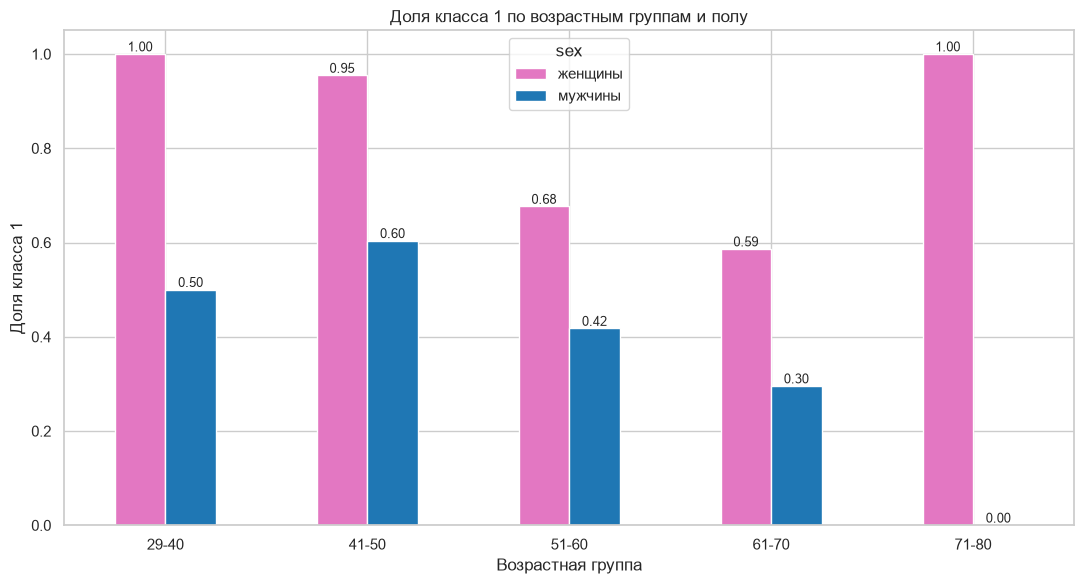

Количество наблюдений в каждой ячейке:
sex         0   1
age_group        
29-40       5  12
41-50      22  53
51-60      34  91
61-70      29  44
71-80       5   1


In [23]:
pivot = df.pivot_table(index='age_group', columns='sex', values=target,
                       aggfunc='mean', observed=True)
sizes = df.pivot_table(index='age_group', columns='sex', values=target,
                       aggfunc='size', observed=True)

ax = pivot.plot(kind='bar', figsize=(11, 6), rot=0,
                color=['#e377c2', '#1f77b4'])
ax.set_ylabel('Доля класса 1')
ax.set_xlabel('Возрастная группа')
ax.set_title('Доля класса 1 по возрастным группам и полу')
ax.legend(title='sex', labels=['женщины', 'мужчины'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig('risk_by_age_sex.png', dpi=120)
plt.show()

print('Количество наблюдений в каждой ячейке:')
print(sizes.to_string())

### Вывод

- Доля класса 1 монотонно падает с возрастом у обеих групп: у мужчин с 0.50 (29–40 лет)
  до 0.30 (61–70 лет), у женщин с 1.00 до 0.59.
- На каждом возрастном интервале доля класса 1 у женщин выше, чем у мужчин, — эффект пола
  не объясняется разницей в возрасте, это самостоятельный фактор.
- Крайние группы (`29-40` и `71-80`) содержат менее 20 наблюдений, поэтому доли 1.00
  в них не показательны. В модели эти группы лучше объединять с соседними.

## Замечание о разметке целевой переменной

Источник описывает `target = 1` как наличие заболевания. Однако все выявленные связи
указывают на обратное: класс 1 — это высокий максимальный пульс, нулевая депрессия ST,
отсутствие стенокардии при нагрузке и `ca = 0`, то есть набор **благоприятных** клинических
показателей. Такая инверсия меток известна для публикаций этого датасета.

На постановку задачи это не влияет — классификатор обучается на тех же данных независимо
от названия классов, — но при интерпретации предсказаний в сервисе (ЛР3) порядок меток
нужно перепроверить по документации конкретного источника.

# 4. Сохранение финального датасета

In [24]:
print('Итоговый размер выборки:', df.shape)
print('Столбцы:', list(df.columns))
df.head()

Итоговый размер выборки: (296, 15)
Столбцы: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'age_group']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,61-70
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,29-40
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,41-50
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,51-60
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,51-60


In [25]:
with open('../data/clean_data.pkl', 'wb') as f:
    pickle.dump(df, f)

print('Датасет сохранён в ../data/clean_data.pkl')

Датасет сохранён в ../data/clean_data.pkl


Формат `pickle` выбран потому, что он сохраняет типы данных столбцов: приведённые к `int8`
категориальные признаки и категориальный тип `age_group` не пришлось бы восстанавливать вручную,
как это было бы при сохранении в CSV.

# 5. Выводы

## Что сделано при очистке данных

1. Удалена 1 полностью дублирующаяся запись.
2. Удалены 4 записи со значением `ca = 4` и 2 записи со значением `thal = 0` — эти значения
   выходят за границы кодировки признаков и являются замаскированными пропусками исходного
   датасета UCI. (Всего строк с `ca = 4` было пять, но одна из них совпала с дубликатом
   из п.1.) Итого удалено 6 записей из 303, итоговый размер выборки — **296 строк**.
3. Проверены диапазоны всех числовых признаков — невалидных значений не обнаружено.
4. Пропущенных значений в датасете нет, восстанавливать ничего не потребовалось.
5. Понижена разрядность типов: категориальные признаки и `target` приведены к `int8`,
   `trestbps`, `chol`, `thalach` — к `int16`, `oldpeak` — к `float32`.

## Созданные признаки

- `age_group` — возрастная группа (биннинг `age` по десятилетиям: 29–40, 41–50, 51–60, 61–70, 71–80).
  Используется для анализа долей классов между когортами.

## Выявленные закономерности

- Наиболее информативные признаки по корреляции с целевой переменной: `ca` (−0.47),
  `oldpeak` (−0.43), `thalach` (+0.43), `exang` (−0.43), `cp` (+0.42)
  (см. график `correlation.png`).
- `thalach` разделяет классы лучше всех числовых признаков: медианы 161 против 141 уд/мин
  (см. `numeric_boxplot.html`, `numeric_by_target.png`).
- `oldpeak` у класса 1 в подавляющем большинстве случаев равен нулю — признак работает
  почти как бинарный индикатор (см. `numeric_by_target.png`).
- `ca` даёт строго монотонную зависимость: доля класса 1 падает с 0.75 при `ca = 0`
  до 0.15 при `ca = 3` (см. `categorical_by_target.png`).
- Пол — самостоятельный фактор: доля класса 1 у женщин выше мужской в каждой возрастной
  группе, а не за счёт разницы в возрасте (см. `risk_by_age_sex.png`).
- `thalach` не сводится к возрасту: разрыв между классами сохраняется на всём возрастном
  диапазоне (см. `thalach_vs_age.png`).
- Кандидаты на исключение при отборе признаков: `fbs` (корреляция −0.005) и `chol` (−0.08).
  Признаки `slope` и `oldpeak` дублируют друг друга (взаимная корреляция −0.58),
  разумно оставить один из них.
- Числовые признаки различаются по масштабу на два порядка, поэтому в пайплайне модели
  обязательна нормировка (`StandardScaler`).

Обработанная выборка сохранена в файл `../data/clean_data.pkl`.